# Word2vec

In [15]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())
else:
    print("Running on CPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4080
Current device: 0


In [16]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
print(df.head())
print(df.columns)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='str')


In [18]:
df = df.dropna()              # clean missing values
df = df.sample(1000, random_state=42)  # take 1k random rows

print(df.shape)
print(df.head())

(1000, 2)
                                                  review sentiment
25480  A somewhat typical bit of filmmaking from this...  positive
37915  I haven't seen this film for over 20 years, bu...  positive
26089  Terry and June was one of the classic British ...  positive
29046  Stupid horror film about five 20 somethings (3...  negative
12083  There's nothing really to dislike about "The O...  positive


# Preprocessing for word2vec

In [20]:
import pandas as pd
import re

df = pd.read_csv("IMDB Dataset.csv")

df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["review"].apply(clean_text)

# tokenize
sentences = df["clean_text"].apply(lambda x: x.split()).tolist()

# Train word2vec

In [21]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # embedding dimension
    window=5,
    min_count=2,
    workers=4,
    sg=1               # 1 = skip-gram, 0 = CBOW
)

w2v_model.save("imdb_word2vec.model")

# View vector of 100 words 

##### Word2vsc is high-D. So it is impossible to visualize on 2D. For that we have
##### its dimenstion by dimension reduction. We use PCA or t-SNE dimension reduction

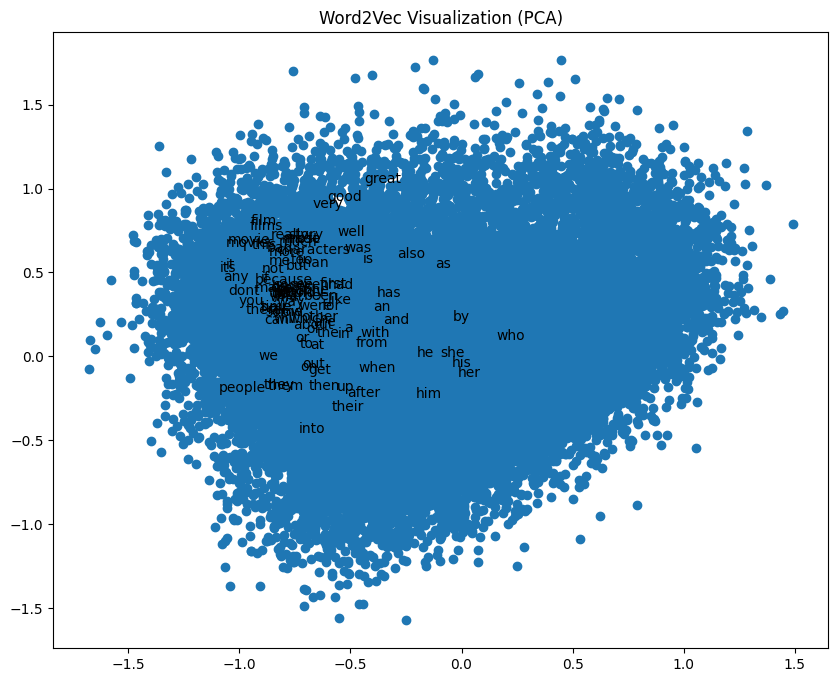

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# get word vectors
words = list(w2v_model.wv.index_to_key)
vectors = np.array([w2v_model.wv[word] for word in words])

# reduce to 2D
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

# plot
plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words[:100]):  # plot only first 100 words
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word2Vec Visualization (PCA)")
plt.show()

## t-SNE

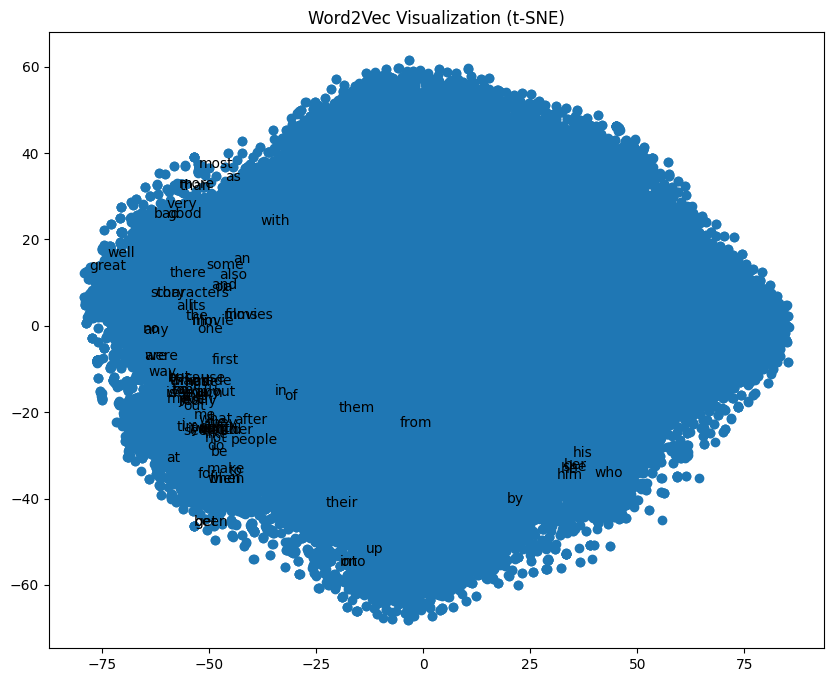

In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

words = list(w2v_model.wv.index_to_key)
vectors = np.array([w2v_model.wv[word] for word in words])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
result = tsne.fit_transform(vectors)

plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words[:100]):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word2Vec Visualization (t-SNE)")
plt.show()

## Converting each review into a single vector

In [22]:
import numpy as np

def get_review_vector(words, model, vector_size=100):
    vectors = []
    for w in words:
        if w in model.wv:
            vectors.append(model.wv[w])
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X = np.array([get_review_vector(words, w2v_model) for words in sentences])
y = df["label"].values

# Logistic Regression

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

Accuracy: 0.867


In [40]:
new_review = "This movie is absolutely amazing"

cleaned = clean_text(new_review)
tokens = cleaned.split()

vec = get_review_vector(tokens, w2v_model)

prediction = clf.predict([vec])

print("Prediction:", prediction)

ValueError: X has 100 features, but LogisticRegression is expecting 2 features as input.